<a href="https://colab.research.google.com/github/Kari-2005/carisurg-portfolio/blob/main/notebooks/Week5_Final_AnsarahMohammed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 5 Final: AI-Assisted Triage Data Exploration

**Student:** Ansarah Mohammed  
**Programme:** CariSurg MedTech Pathways  
**Task:** Week 5 Final Deliverable  

## Aim

This notebook explores the ED triage dataset to assess whether it is suitable for building a baseline triage model in Week 6.

The analysis focuses on:
- dataset size and structure
- missingness and data completeness
- ESI triage level balance
- demographic representation
- chief complaint patterns
- vital sign quality and outliers
- possible leakage columns
- simple feature association with ESI
- final top-10 feature shortlist

In [131]:
# Mounting the google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [132]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# General display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

# Consistent plot settings
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

# Colour palette for consistent visuals
main_colour = "#0E6BA8"
second_colour = "#00A6A6"
accent_colour = "#F28C28"
warning_colour = "#C44536"
neutral_colour = "#6C757D"

print("Libraries imported and plot style set.")

Libraries imported and plot style set.


In [133]:
# Path to the dataset in Google Drive
file_path = "/content/drive/MyDrive/CARISURG/Week5/yaleemmlc_admissionprediction_triage.csv"

# Folder where plots and outputs will be saved
output_folder = "/content/drive/MyDrive/CARISURG/Week5/final"
os.makedirs(output_folder, exist_ok=True)

print("Dataset path:", file_path)
print("Output folder:", output_folder)

Dataset path: /content/drive/MyDrive/CARISURG/Week5/yaleemmlc_admissionprediction_triage.csv
Output folder: /content/drive/MyDrive/CARISURG/Week5/final


In [134]:
# Loading the dataset
df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully.
Dataset shape: (55121, 226)


,Unnamed: 0,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,insurance_status,disposition,arrivalmode,arrivalmonth,arrivalday,arrivalhour_bin,previousdispo,triage_vital_hr,triage_vital_sbp,triage_vital_dbp,triage_vital_rr,triage_vital_o2,triage_vital_o2_device,triage_vital_temp,triage_glucose,cc_abdominalcramping,cc_abdominaldistention,cc_abdominalpain,cc_abdominalpainpregnant,cc_abnormallab,cc_abscess,cc_addictionproblem,cc_agitation,cc_alcoholintoxication,cc_alcoholproblem,cc_allergicreaction,cc_alteredmentalstatus,cc_animalbite,cc_ankleinjury,cc_anklepain,cc_anxiety,cc_arminjury,cc_armpain,cc_armswelling,cc_assaultvictim,cc_asthma,cc_backpain,cc_bleeding/bruising,cc_blurredvision,...,cc_post-opproblem,cc_psychiatricevaluation,cc_psychoticsymptoms,cc_rapidheartrate,cc_rash,cc_rectalbleeding,cc_rectalpain,cc_respiratorydistress,cc_ribinjury,cc_ribpain,cc_seizure-newonset,cc_seizure-priorhxof,cc_seizures,cc_shortnessofbreath,cc_shoulderinjury,cc_shoulderpain,cc_sicklecellpain,cc_sinusproblem,cc_skinirritation,cc_skinproblem,cc_sorethroat,cc_stdcheck,cc_strokealert,cc_suicidal,cc_suture/stapleremoval,cc_swallowedforeignbody,cc_syncope,cc_tachycardia,cc_testiclepain,cc_thumbinjury,cc_tickremoval,cc_toeinjury,cc_toepain,cc_trauma,cc_unresponsive,cc_uri,cc_urinaryfrequency,cc_urinaryretention,cc_urinarytractinfection,cc_vaginalbleeding,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,Retired,Medicare,Discharge,Car,March,Saturday,11-14,Admit,88.0,155.0,75.0,17.0,98.0,0.0,97.8,87.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,17,B,2.0,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,Disabled,Medicare,Admit,Walk-in,September,Monday,11-14,Discharge,118.0,105.0,79.0,20.0,98.0,0.0,97.5,113.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,40,A,2.0,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,Full Time,Commercial,Discharge,ambulance,June,Tuesday,15-18,Admit,76.0,116.0,71.0,18.0,99.0,0.0,98.1,108.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,47,A,3.0,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,Full Time,Commercial,Discharge,Car,April,Sunday,23-02,Discharge,106.0,103.0,63.0,16.0,97.0,0.0,98.2,85.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,60,A,2.0,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,Not Employed,Medicaid,Discharge,ambulance,July,Wednesday,23-02,Discharge,84.0,109.0,68.0,18.0,95.0,0.0,97.8,88.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [135]:
## Dataset Summary
## This table summarises the basic structure of the dataset, including the
## number of encounters, number of columns, missing values, chief complaint
## flags, and target variable.

cc_cols = [col for col in df.columns if col.startswith("cc_")]

dataset_summary = pd.DataFrame({
    "Item": [
        "Number of ED encounters",
        "Number of columns",
        "Number of chief complaint flags",
        "Total missing values",
        "Target variable",
        "Number of ESI levels"
    ],
    "Finding": [
        df.shape[0],
        df.shape[1],
        len(cc_cols),
        df.isna().sum().sum(),
        "esi",
        df["esi"].nunique()
    ]
})

dataset_summary

,Item,Finding
0,Number of ED encounters,55121
1,Number of columns,226
2,Number of chief complaint flags,200
3,Total missing values,0
4,Target variable,esi
5,Number of ESI levels,5


In [136]:
## Data Types and Column Families
## I reviewed the data types and grouped the columns into broad families. This
## helps separate variables that are available at triage time from variables
## that may create leakage or need to be excluded during modelling.

dtype_summary = df.dtypes.value_counts()

print("Data type summary:")
print(dtype_summary)

vital_cols = [
    "triage_vital_hr",
    "triage_vital_sbp",
    "triage_vital_dbp",
    "triage_vital_rr",
    "triage_vital_o2",
    "triage_vital_o2_device",
    "triage_vital_temp",
    "triage_glucose"
]

existing_vital_cols = [col for col in vital_cols if col in df.columns]

column_family_summary = pd.DataFrame({
    "Column family": [
        "Demographics/context",
        "Triage vital signs",
        "Chief complaint flags",
        "Target variable",
        "Potential leakage-risk columns"
    ],
    "Examples": [
        "age, gender, race, ethnicity, language, insurance status",
        ", ".join(existing_vital_cols),
        f"{len(cc_cols)} columns beginning with cc_",
        "esi",
        "disposition, previousdispo"
    ]
})

column_family_summary

Data type summary:
float64    210
object      15
int64        1
Name: count, dtype: int64


,Column family,Examples
0,Demographics/context,"age, gender, race, ethnicity, language, insura..."
1,Triage vital signs,"triage_vital_hr, triage_vital_sbp, triage_vita..."
2,Chief complaint flags,200 columns beginning with cc_
3,Target variable,esi
4,Potential leakage-risk columns,"disposition, previousdispo"


## Missingness Check

Missing values were checked for every column. This is important because missing clinical data can affect whether the dataset is suitable for modelling. In this dataset, no missing values were found, which is reassuring for completeness but does not remove the need to check class balance, outliers, leakage, and representativeness.

In [137]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().sum() / len(df)) * 100
}).sort_values("missing_percent", ascending=False)

missing_summary.head(20)

,missing_count,missing_percent
Unnamed: 0,0,0.0
dep_name,0,0.0
esi,0,0.0
age,0,0.0
gender,0,0.0
ethnicity,0,0.0
race,0,0.0
lang,0,0.0
religion,0,0.0
maritalstatus,0,0.0


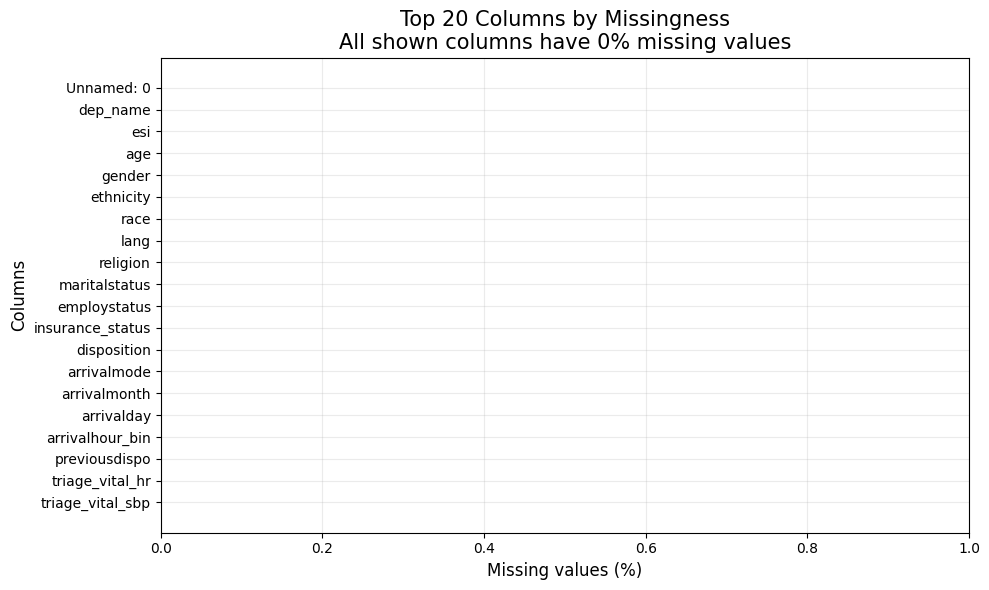

Missingness plot saved to:
/content/drive/MyDrive/CARISURG/Week5/final/week5_missingness_plot.png


In [138]:
## Missingness Visualisation
## A missingness plot was created for the Week 5 submission. This visual
## helps show whether any columns have missing values that may affect modelling.

# Select top 20 columns by missing percentage
top_missing = missing_summary.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top_missing.index, top_missing["missing_percent"])

plt.xlabel("Missing values (%)")
plt.ylabel("Columns")
plt.title("Top 20 Columns by Missingness\nAll shown columns have 0% missing values")

# Make the zero values easier to interpret
plt.xlim(0, 1)

plt.gca().invert_yaxis()
plt.tight_layout()

missing_plot_path = os.path.join(output_folder, "week5_missingness_plot.png")
plt.savefig(missing_plot_path, dpi=300, bbox_inches="tight")

plt.show()

print("Missingness plot saved to:")
print(missing_plot_path)

### Interpretation

The missingness check found 0% missing values across the checked columns. This supports data completeness. However, missingness alone does not determine whether the dataset is suitable for modelling, so the next checks focus on ESI class balance, demographic representation, outliers, and leakage-risk columns.

## ESI Triage Level Distribution

The target variable is `esi`, which represents Emergency Severity Index triage level. ESI 1 is the most urgent and ESI 5 is the least urgent. The distribution of ESI levels is important because rare classes may be harder for a baseline model to learn.

In [139]:
esi_counts = df["esi"].value_counts().sort_index()
esi_percent = (esi_counts / len(df)) * 100

esi_summary = pd.DataFrame({
    "ESI level": esi_counts.index.astype(int),
    "count": esi_counts.values,
    "percent": esi_percent.round(2).values
})

esi_summary

,ESI level,count,percent
0,1,77,0.14
1,2,17924,32.52
2,3,27010,49.00
3,4,8896,16.14
4,5,1214,2.20


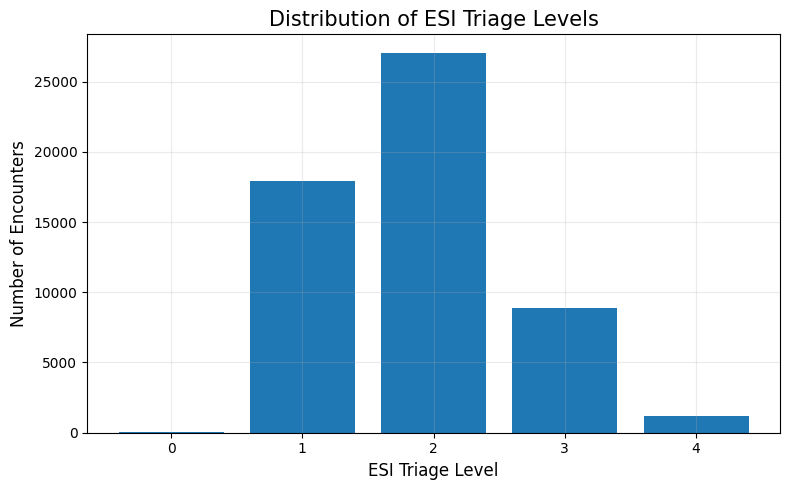

ESI distribution plot saved to:
/content/drive/MyDrive/CARISURG/Week5/final/week5_esi_distribution.png


In [140]:
## ESI Class Distribution
## I plotted the distribution of ESI triage levels to check whether the dataset
## is balanced across urgency categories. This is important because very rare
## classes may be harder for a model to learn.

plt.figure(figsize=(8, 5))
plt.bar(esi_summary.index.astype(str), esi_summary["count"])
plt.xlabel("ESI Triage Level")
plt.ylabel("Number of Encounters")
plt.title("Distribution of ESI Triage Levels")
plt.tight_layout()

esi_plot_path = os.path.join(output_folder, "week5_esi_distribution.png")
plt.savefig(esi_plot_path, dpi=300, bbox_inches="tight")

plt.show()

print("ESI distribution plot saved to:")
print(esi_plot_path)

## Demographic Variables
I reviewed selected demographic variables such as age, gender, race and ethnicity. These variables help describe the patient population and may also raise questions about representativeness and fairness.

In [141]:
demographic_cols = ["age", "gender", "race", "ethnicity"]

for col in demographic_cols:
    if col in df.columns:
        print("\nColumn:", col)
        print(df[col].value_counts(dropna=False).head(10))


Column: age
age
53.0    1285
54.0    1278
52.0    1196
55.0    1185
57.0    1156
59.0    1139
51.0    1131
56.0    1126
58.0    1109
50.0    1100
Name: count, dtype: int64

Column: gender
gender
Female    31744
Male      23377
Name: count, dtype: int64

Column: race
race
White or Caucasian                           29435
Black or African American                    15963
Other                                         9016
Patient Refused                                370
Asian                                          175
Unknown                                         76
American Indian or Alaska Native                66
Native Hawaiian or Other Pacific Islander       20
Name: count, dtype: int64

Column: ethnicity
ethnicity
Non-Hispanic          45142
Hispanic or Latino     9888
Patient Refused          56
Unknown                  35
Name: count, dtype: int64


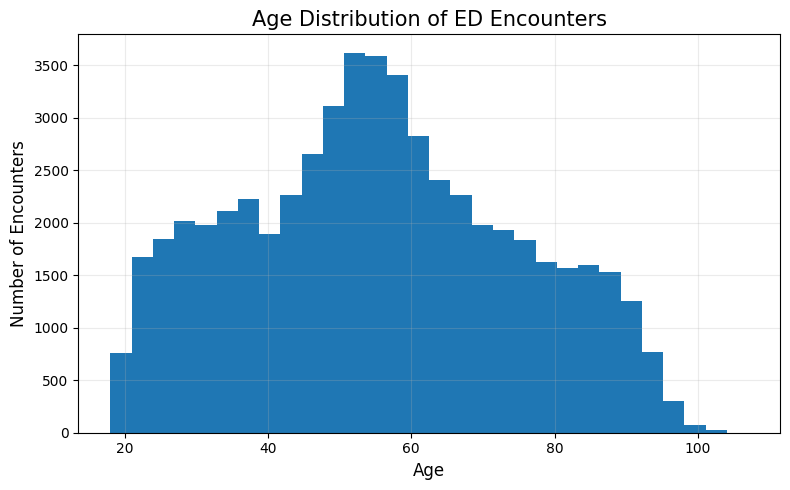

Age distribution plot saved to:
/content/drive/MyDrive/CARISURG/Week5/final/week5_age_distribution.png


In [142]:
## Age Distribution
## Age is clinically relevant in emergency triage because older and younger
## patients may have different risk profiles. I plotted the age distribution to
## understand the patient population.

plt.figure(figsize=(8, 5))
plt.hist(df["age"], bins=30)
plt.xlabel("Age")
plt.ylabel("Number of Encounters")
plt.title("Age Distribution of ED Encounters")
plt.tight_layout()

age_plot_path = os.path.join(output_folder, "week5_age_distribution.png")
plt.savefig(age_plot_path, dpi=300, bbox_inches="tight")

plt.show()

print("Age distribution plot saved to:")
print(age_plot_path)

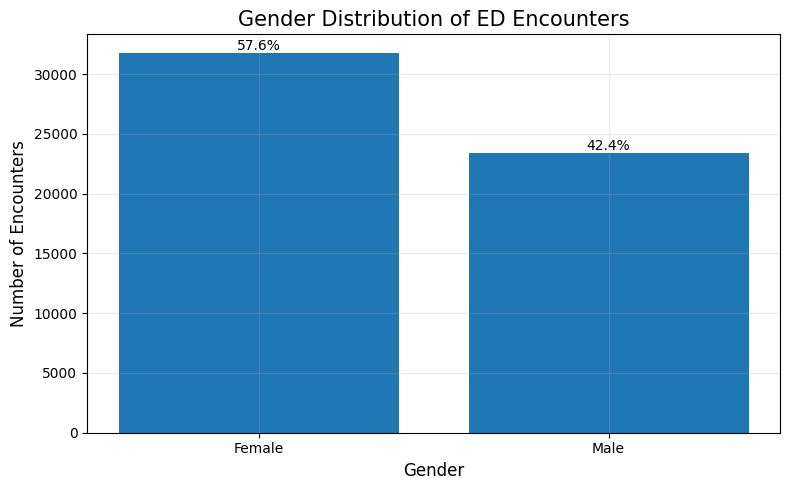

Gender distribution plot saved to:
/content/drive/MyDrive/CARISURG/Week5/final/week5_gender_distribution.png


In [143]:
## Gender Distribution
## Gender distribution was reviewed as part of the demographic exploration.
## This helps describe the patient population and supports the feasibility
## discussion around representativeness and fairness.

if "gender" in df.columns:
    gender_counts = df["gender"].value_counts(dropna=False)
    gender_percent = (gender_counts / len(df)) * 100

    plt.figure(figsize=(8, 5))
    bars = plt.bar(gender_counts.index.astype(str), gender_counts.values)

    plt.xlabel("Gender")
    plt.ylabel("Number of Encounters")
    plt.title("Gender Distribution of ED Encounters")

    for bar, percent in zip(bars, gender_percent):
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{percent:.1f}%",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()

    gender_plot_path = os.path.join(output_folder, "week5_gender_distribution.png")
    plt.savefig(gender_plot_path, dpi=300, bbox_inches="tight")

    plt.show()

    print("Gender distribution plot saved to:")
    print(gender_plot_path)
else:
    print("Gender column not found.")

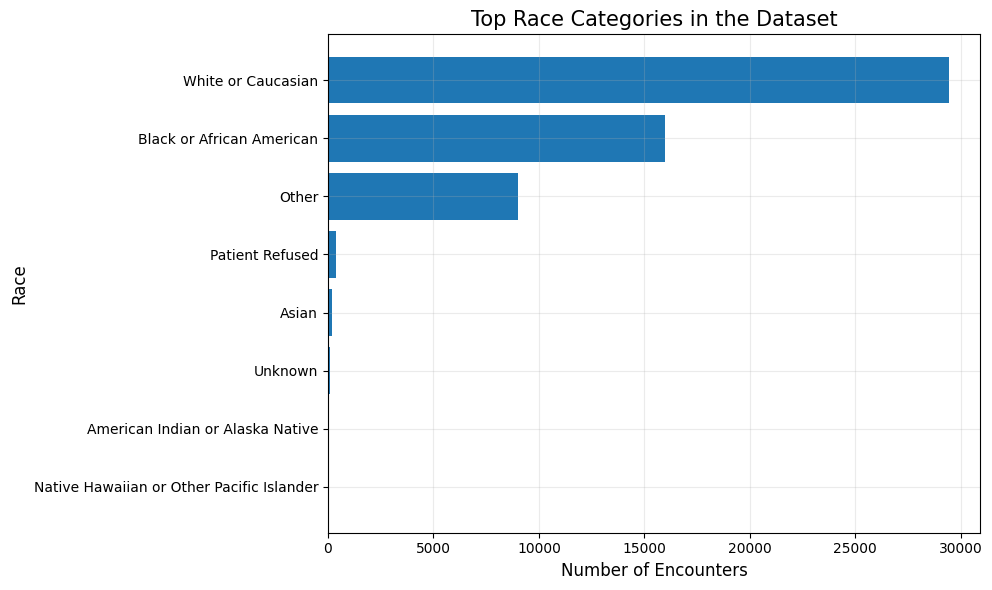

Race distribution plot saved to:
/content/drive/MyDrive/CARISURG/Week5/final/week5_race_distribution.png


In [144]:
## Race Distribution
## Race distribution was reviewed because the Week 5 task asks for exploration
## of race and ethnicity. This also helps identify whether the dataset may
## represent some groups more than others.

if "race" in df.columns:
    race_counts = df["race"].value_counts().head(10)

    plt.figure(figsize=(10, 6))
    plt.barh(race_counts.index.astype(str), race_counts.values)
    plt.xlabel("Number of Encounters")
    plt.ylabel("Race")
    plt.title("Top Race Categories in the Dataset")
    plt.gca().invert_yaxis()
    plt.tight_layout()

    race_plot_path = os.path.join(output_folder, "week5_race_distribution.png")
    plt.savefig(race_plot_path, dpi=300, bbox_inches="tight")

    plt.show()

    print("Race distribution plot saved to:")
    print(race_plot_path)
else:
    print("Race column not found.")

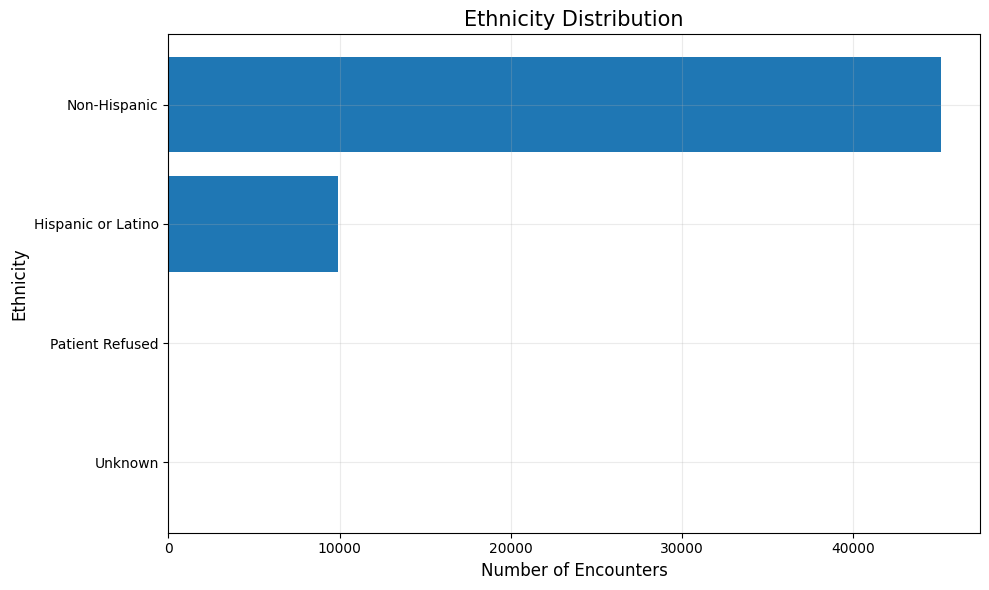

Ethnicity plot saved to:
/content/drive/MyDrive/CARISURG/Week5/final/week5_visuals/week5_ethnicity_distribution.png


In [145]:
## Ethnicity Distribution
## Ethnicity was reviewed because demographic representation is important when
## assessing whether this dataset may generalise to a Caribbean emergency
## department setting. A dataset can be complete and still have representation
## concerns if some groups are much more common than others.

# Make sure the visuals folder exists
visuals_folder = os.path.join(output_folder, "week5_visuals")
os.makedirs(visuals_folder, exist_ok=True)

if "ethnicity" in df.columns:
    ethnicity_counts = df["ethnicity"].value_counts().head(10)

    plt.figure(figsize=(10, 6))
    plt.barh(ethnicity_counts.index.astype(str), ethnicity_counts.values)
    plt.xlabel("Number of Encounters")
    plt.ylabel("Ethnicity")
    plt.title("Ethnicity Distribution")
    plt.gca().invert_yaxis()
    plt.tight_layout()

    ethnicity_plot_path = os.path.join(visuals_folder, "week5_ethnicity_distribution.png")
    plt.savefig(ethnicity_plot_path, dpi=300, bbox_inches="tight")

    plt.show()

    print("Ethnicity plot saved to:")
    print(ethnicity_plot_path)
else:
    print("Ethnicity column not found.")

## ESI Distribution by Race
This plot checks whether ESI levels are distributed differently across the largest race categories. It is descriptive only and does not prove bias.

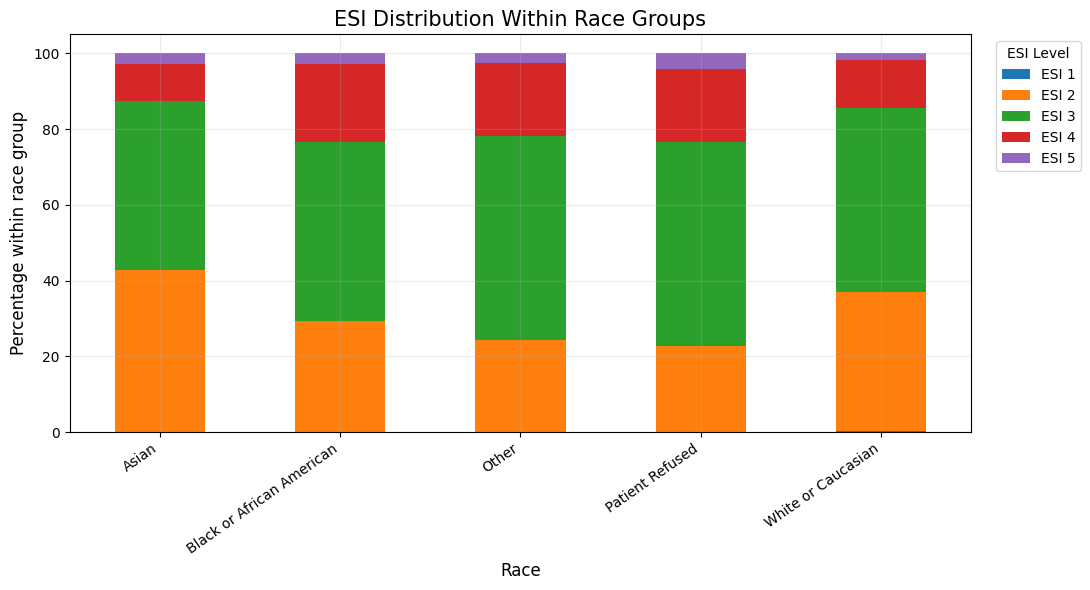

ESI by race plot saved to:
/content/drive/MyDrive/CARISURG/Week5/final/week5_visuals/week5_esi_distribution_by_race.png


In [146]:
visuals_folder = os.path.join(output_folder, "week5_visuals")
os.makedirs(visuals_folder, exist_ok=True)

if "race" in df.columns and "esi" in df.columns:
    top_races = df["race"].value_counts().head(5).index

    race_esi = pd.crosstab(
        df.loc[df["race"].isin(top_races), "race"],
        df.loc[df["race"].isin(top_races), "esi"],
        normalize="index"
    ) * 100

    race_esi = race_esi[[col for col in sorted(race_esi.columns) if col in race_esi.columns]]
    race_esi.columns = [f"ESI {int(col)}" for col in race_esi.columns]

    ax = race_esi.plot(kind="bar", stacked=True, figsize=(11, 6))

    plt.xlabel("Race")
    plt.ylabel("Percentage within race group")
    plt.title("ESI Distribution Within Race Groups")
    plt.xticks(rotation=35, ha="right")
    plt.legend(title="ESI Level", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()

    race_esi_plot_path = os.path.join(visuals_folder, "week5_esi_distribution_by_race.png")
    plt.savefig(race_esi_plot_path, dpi=300, bbox_inches="tight")

    plt.show()

    print("ESI by race plot saved to:")
    print(race_esi_plot_path)
else:
    print("Race or ESI column not found.")

### Interpretation

This plot compares the percentage distribution of ESI levels within the largest race categories. It supports the feasibility memo discussion on representativeness and fairness. Because some race categories have much smaller counts than others, this figure should be interpreted cautiously and should not be used by itself to claim bias.

## Chief Complaint Features
The dataset contains many chief complaint flag columns beginning with `cc_`. These represent symptoms or reasons for visiting the emergency department. I counted these columns and identified the most common complaints.

In [147]:
cc_cols = [col for col in df.columns if col.startswith("cc_")]

print("Number of chief complaint columns:", len(cc_cols))

# Count how often each chief complaint appears
cc_counts = df[cc_cols].sum().sort_values(ascending=False)

cc_counts.head(15)

Number of chief complaint columns: 200


,0
cc_abdominalpain,6717.0
cc_other,4491.0
cc_chestpain,3712.0
cc_shortnessofbreath,3098.0
cc_backpain,1997.0
cc_fall,1926.0
cc_cough,1439.0
cc_dizziness,1292.0
cc_legpain,1264.0
cc_emesis,1249.0


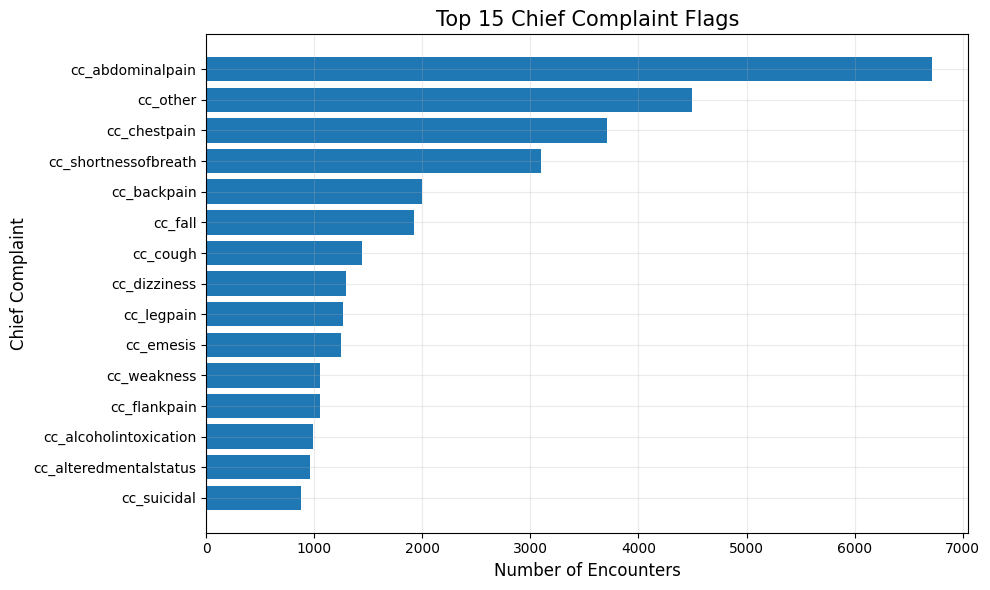

Chief complaint plot saved to:
/content/drive/MyDrive/CARISURG/Week5/final/week5_top_chief_complaints.png


In [148]:
## Most Common Chief Complaints
## I plotted the most common chief complaints to understand the types of
## cases represented in the dataset.

top_cc = cc_counts.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_cc.index, top_cc.values)
plt.xlabel("Number of Encounters")
plt.ylabel("Chief Complaint")
plt.title("Top 15 Chief Complaint Flags")
plt.gca().invert_yaxis()
plt.tight_layout()

cc_plot_path = os.path.join(output_folder, "week5_top_chief_complaints.png")
plt.savefig(cc_plot_path, dpi=300, bbox_inches="tight")

plt.show()

print("Chief complaint plot saved to:")
print(cc_plot_path)

## Vital Sign Summary
Triage vital signs are clinically important because they reflect the
patient’s condition at arrival. These values are likely to be useful for
a baseline triage model, but they should also be checked for unusual or clinically unrealistic values before modelling.


In [149]:
vital_cols = [
    "triage_vital_hr",
    "triage_vital_sbp",
    "triage_vital_dbp",
    "triage_vital_rr",
    "triage_vital_o2",
    "triage_vital_o2_device",
    "triage_vital_temp",
    "triage_glucose"
]

# Only keep columns that actually exist in the dataset
existing_vital_cols = [col for col in vital_cols if col in df.columns]

vital_summary = df[existing_vital_cols].describe().T

vital_summary

,count,mean,std,min,25%,50%,75%,max
triage_vital_hr,55121.0,86.447618,16.955556,32.0,74.0,85.0,97.0,221.0
triage_vital_sbp,55121.0,133.680403,22.645812,53.0,118.0,132.0,147.0,266.0
triage_vital_dbp,55121.0,79.531401,14.594082,27.0,70.0,79.0,89.0,189.0
triage_vital_rr,55121.0,17.842073,2.066015,8.0,16.0,18.0,18.0,66.0
triage_vital_o2,55121.0,97.021393,2.084465,62.0,96.0,98.0,98.0,99.0
triage_vital_o2_device,55121.0,0.065510,0.247427,0.0,0.0,0.0,0.0,1.0
triage_vital_temp,55121.0,98.090311,0.813266,91.5,97.7,98.0,98.4,106.0
triage_glucose,55121.0,130.086138,73.664073,16.0,93.0,107.0,134.0,1066.0


In [150]:
## Save Vital Sign Summary
## The vital sign summary was saved so that it can be used as supporting
## evidence for the Week 5 feasibility memo.

vital_summary_path = os.path.join(output_folder, "week5_vital_sign_summary.csv")

vital_summary.to_csv(vital_summary_path)

print("Vital sign summary saved to:")
print(vital_summary_path)

Vital sign summary saved to:
/content/drive/MyDrive/CARISURG/Week5/final/week5_vital_sign_summary.csv


## Outlier and Clinical Range Checks
I checked selected features against broad clinical plausibility ranges. These checks are not used to diagnose patients. They are used to identify values that may need review before Week 6 modelling.


In [151]:
range_checks = {
    "age": (0, 120),
    "triage_vital_hr": (30, 220),
    "triage_vital_sbp": (50, 260),
    "triage_vital_dbp": (30, 180),
    "triage_vital_rr": (8, 60),
    "triage_vital_o2": (50, 100),
    "triage_vital_temp": (90, 106),
    "triage_glucose": (20, 1000)
}

outlier_results = []

for col, (low, high) in range_checks.items():
    if col in df.columns:
        below = (df[col] < low).sum()
        above = (df[col] > high).sum()
        total_flagged = below + above

        outlier_results.append({
            "feature": col,
            "low_threshold": low,
            "high_threshold": high,
            "below_range": below,
            "above_range": above,
            "total_flagged": total_flagged,
            "percent_flagged": round((total_flagged / len(df)) * 100, 2)
        })

outlier_table = pd.DataFrame(outlier_results)

outlier_table

,feature,low_threshold,high_threshold,below_range,above_range,total_flagged,percent_flagged
0,age,0,120,0,0,0,0.00
1,triage_vital_hr,30,220,0,1,1,0.00
2,triage_vital_sbp,50,260,0,1,1,0.00
3,triage_vital_dbp,30,180,7,2,9,0.02
4,triage_vital_rr,8,60,0,4,4,0.01
5,triage_vital_o2,50,100,0,0,0,0.00
6,triage_vital_temp,90,106,0,0,0,0.00
7,triage_glucose,20,1000,4,4,8,0.01


In [152]:
## Save Outlier Table
## The outlier table was saved to document possible data quality issues for
## the feasibility memo.

outlier_table_path = os.path.join(output_folder, "week5_outlier_check_table.csv")

outlier_table.to_csv(outlier_table_path, index=False)

print("Outlier table saved to:")
print(outlier_table_path)

Outlier table saved to:
/content/drive/MyDrive/CARISURG/Week5/final/week5_outlier_check_table.csv


## Vital Signs by ESI Level
I compared selected vital signs across ESI levels to see whether clinical measurements vary by triage urgency. Since ESI 1 is the most urgent and ESI 5 is the least urgent, these plots help identify whether vital signs show meaningful patterns across triage categories.

/tmp/ipykernel_4217/1951362803.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


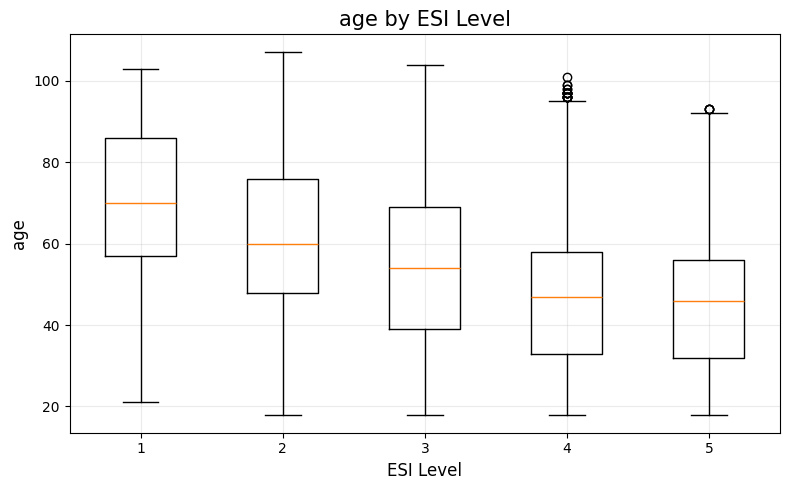

Saved: /content/drive/MyDrive/CARISURG/Week5/final/week5_visuals/week5_age_by_esi.png


/tmp/ipykernel_4217/1951362803.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


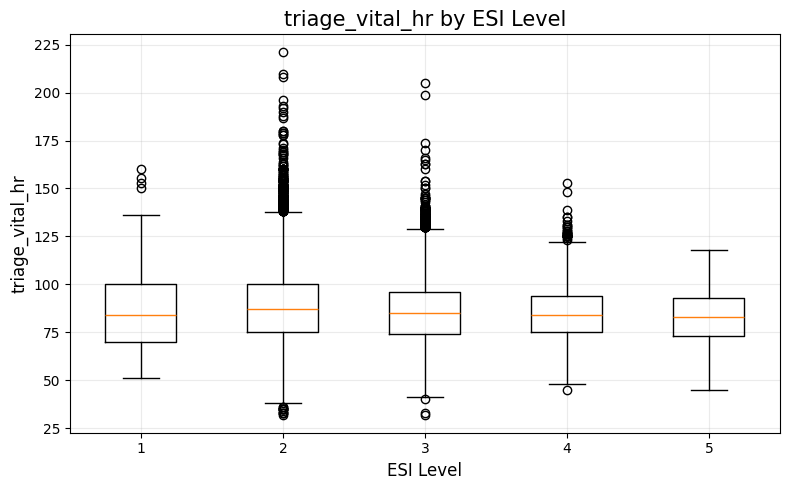

Saved: /content/drive/MyDrive/CARISURG/Week5/final/week5_visuals/week5_triage_vital_hr_by_esi.png


/tmp/ipykernel_4217/1951362803.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


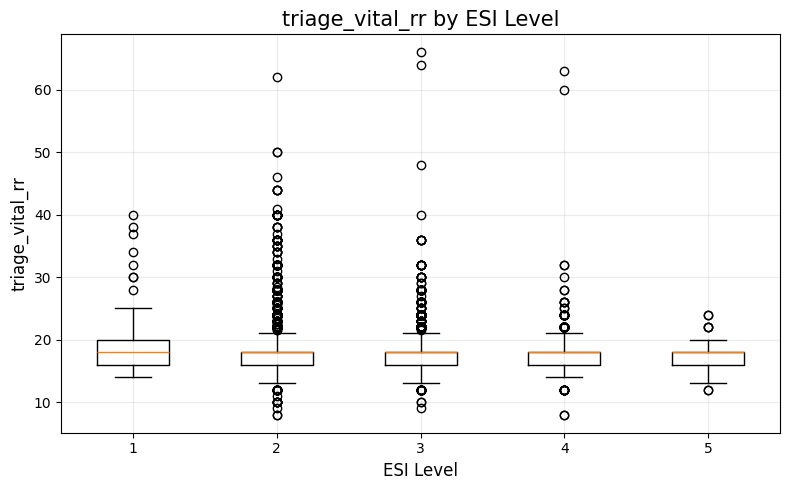

Saved: /content/drive/MyDrive/CARISURG/Week5/final/week5_visuals/week5_triage_vital_rr_by_esi.png


/tmp/ipykernel_4217/1951362803.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


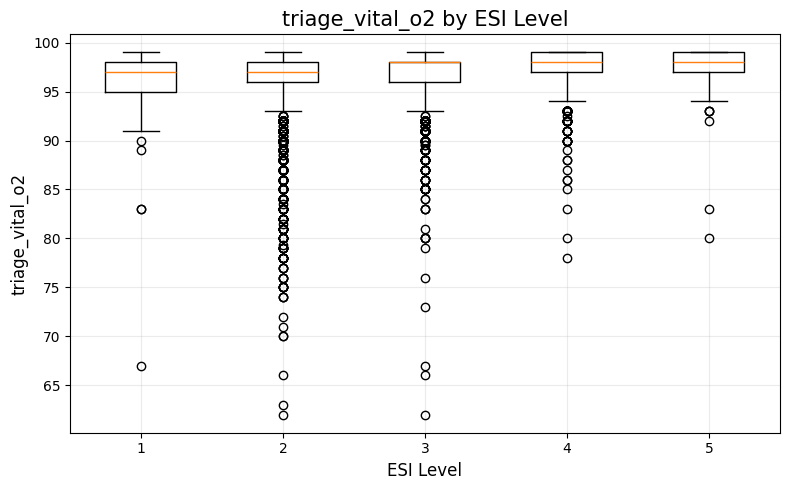

Saved: /content/drive/MyDrive/CARISURG/Week5/final/week5_visuals/week5_triage_vital_o2_by_esi.png


/tmp/ipykernel_4217/1951362803.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


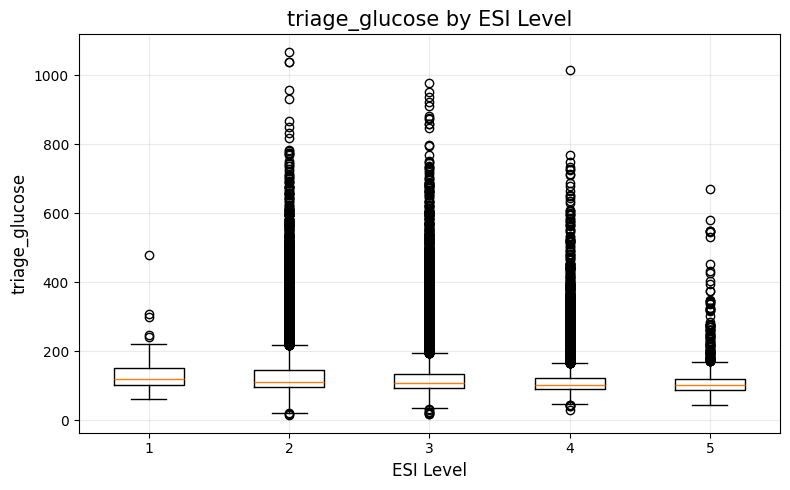

Saved: /content/drive/MyDrive/CARISURG/Week5/final/week5_visuals/week5_triage_glucose_by_esi.png


In [153]:
selected_vitals = [
    "age",
    "triage_vital_hr",
    "triage_vital_rr",
    "triage_vital_o2",
    "triage_glucose"
]

for col in selected_vitals:
    if col in df.columns:
        data_by_esi = [
            df[df["esi"] == level][col].dropna()
            for level in sorted(df["esi"].unique())
        ]

        plt.figure(figsize=(8, 5))
        plt.boxplot(
            data_by_esi,
            labels=[str(int(level)) for level in sorted(df["esi"].unique())]
        )
        plt.xlabel("ESI Level")
        plt.ylabel(col)
        plt.title(f"{col} by ESI Level")
        plt.tight_layout()

        plot_path = os.path.join(visuals_folder, f"week5_{col}_by_esi.png")
        plt.savefig(plot_path, dpi=300, bbox_inches="tight")

        plt.show()
        print("Saved:", plot_path)

## Potential Leakage Columns
Some variables may contain information that would not be available at the time of triage. These should not be used as model inputs in Week 6 because they could make the model appear more accurate than it would be in real clinical use. For this dataset, `disposition` and `previousdispo` are treated as leakage-risk columns because they relate to what happened after or before the current ED visit, rather than only what is known at triage.


In [154]:
leakage_cols = ["disposition", "previousdispo"]

for col in leakage_cols:
    if col in df.columns:
        print("\nColumn:", col)
        print(df[col].value_counts().head(10))
    else:
        print(col, "not found in dataset.")


Column: disposition
disposition
Discharge    34565
Admit        20556
Name: count, dtype: int64

Column: previousdispo
previousdispo
Discharge                       28627
Admit                           23496
No previous dispo                1239
Transfer to Another Facility      566
LWBS after Triage                 461
AMA                               434
Eloped                            174
LWBS before Triage                 61
Observation                        44
Send to L&D                        19
Name: count, dtype: int64


## Simple Correlation with ESI
 I calculated simple correlations between numeric features and `esi`. This is not a model, and it does not prove prediction. It only helps identify features that move with ESI and may be worth testing in Week 6. Because ESI 1 is the most urgent and ESI 5 is the least urgent, negative correlations may be associated with more urgent triage levels, while positive correlations may be associated with less urgent triage levels.


In [155]:
# Select numeric columns
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Exclude target, index-like column, and leakage-risk columns
exclude_from_corr = ["Unnamed: 0", "esi"] + leakage_cols
numeric_features = [col for col in numeric_cols if col not in exclude_from_corr]

# Calculate correlation with ESI
corr_with_esi = df[numeric_features + ["esi"]].corr(numeric_only=True)["esi"].drop("esi")

corr_table = pd.DataFrame({
    "feature": corr_with_esi.index,
    "correlation_with_esi": corr_with_esi.values,
    "absolute_correlation": corr_with_esi.abs().values
}).sort_values("absolute_correlation", ascending=False)

corr_table.head(20)

,feature,correlation_with_esi,absolute_correlation
0,age,-0.236582,0.236582
6,triage_vital_o2_device,-0.208956,0.208956
5,triage_vital_o2,0.177859,0.177859
40,cc_chestpain,-0.164328,0.164328
172,cc_shortnessofbreath,-0.150285,0.150285
182,cc_suicidal,-0.142603,0.142603
30,cc_backpain,0.142140,0.142140
17,cc_alcoholintoxication,-0.142127,0.142127
163,cc_rash,0.133698,0.133698
20,cc_alteredmentalstatus,-0.131958,0.131958


In [156]:
## Save Correlation Table
## The correlation table was saved as supporting evidence for the final feature
## shortlist. These correlations were used together with clinical reasoning,
## not by themselves.

corr_table_path = os.path.join(output_folder, "week5_correlation_with_esi.csv")

corr_table.to_csv(corr_table_path, index=False)

print("Correlation table saved to:")
print(corr_table_path)

Correlation table saved to:
/content/drive/MyDrive/CARISURG/Week5/final/week5_correlation_with_esi.csv


## Top Numeric Features Associated with ESI
 This plot shows the numeric features with the strongest simple association with ESI. These features are not automatically the best predictors, but they help guide the Week 6 baseline modelling plan.

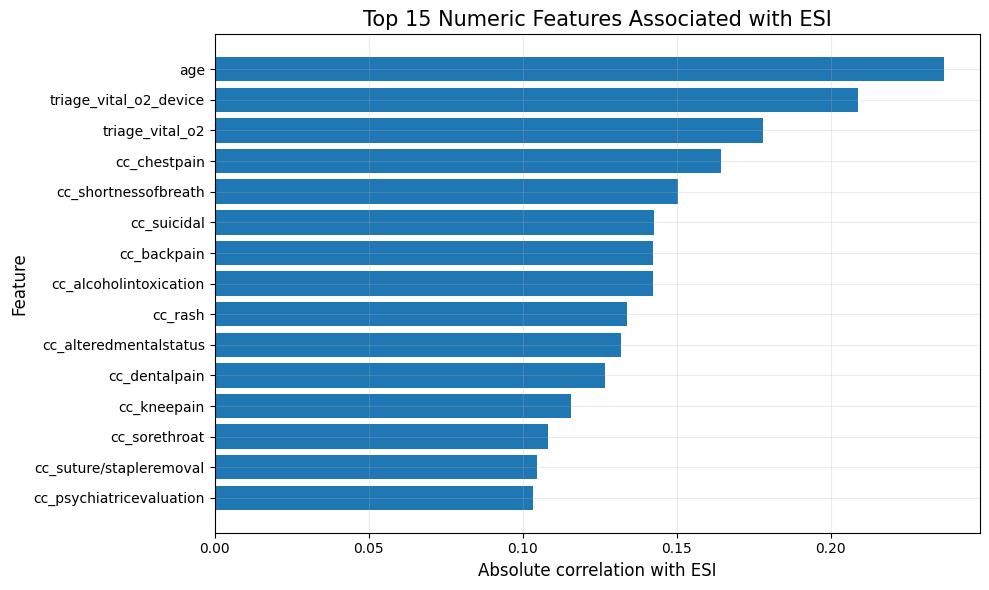

Correlation plot saved to:
/content/drive/MyDrive/CARISURG/Week5/final/week5_visuals/week5_top_correlation_features.png


In [157]:
top_corr = corr_table.head(15).copy()

plt.figure(figsize=(10, 6))
plt.barh(top_corr["feature"], top_corr["absolute_correlation"])
plt.xlabel("Absolute correlation with ESI")
plt.ylabel("Feature")
plt.title("Top 15 Numeric Features Associated with ESI")
plt.gca().invert_yaxis()
plt.tight_layout()

corr_plot_path = os.path.join(visuals_folder, "week5_top_correlation_features.png")
plt.savefig(corr_plot_path, dpi=300, bbox_inches="tight")

plt.show()

print("Correlation plot saved to:")
print(corr_plot_path)

## Final Top-10 Feature Shortlist
This shortlist combines clinical intuition with simple data exploration. It should be treated as a Week 6 modelling hypothesis, not as proof that these are the best final predictors. Leakage-risk columns such as `disposition` and `previousdispo` are excluded.

In [158]:
top10_features = pd.DataFrame({
    "rank": list(range(1, 11)),
    "feature": [
        "age",
        "triage_vital_o2",
        "triage_vital_o2_device",
        "triage_vital_hr",
        "triage_vital_rr",
        "triage_vital_sbp",
        "triage_vital_dbp",
        "triage_vital_temp",
        "triage_glucose",
        "selected chief complaint flags"
    ],
    "reasoning": [
        "Age is clinically relevant because older patients may have higher risk and more complex presentations.",
        "Oxygen saturation reflects respiratory status and can signal deterioration.",
        "Use of an oxygen device may indicate respiratory compromise or higher clinical concern at triage.",
        "Heart rate can reflect pain, fever, shock, anxiety, or acute illness.",
        "Respiratory rate is a key vital sign for identifying respiratory distress.",
        "Systolic blood pressure can indicate hypotension, shock, or severe hypertension.",
        "Diastolic blood pressure adds context to overall blood pressure status.",
        "Temperature can indicate fever, infection, or other acute illness.",
        "Glucose is important for identifying acute metabolic problems such as hypoglycaemia or hyperglycaemia.",
        "Chief complaint flags capture the reason for ED attendance and may identify red-flag presentations such as chest pain, shortness of breath, altered mental status, or suicidal ideation."
    ]
})

top10_features

,rank,feature,reasoning
0,1,age,Age is clinically relevant because older patie...
1,2,triage_vital_o2,Oxygen saturation reflects respiratory status ...
2,3,triage_vital_o2_device,Use of an oxygen device may indicate respirato...
3,4,triage_vital_hr,"Heart rate can reflect pain, fever, shock, anx..."
4,5,triage_vital_rr,Respiratory rate is a key vital sign for ident...
5,6,triage_vital_sbp,Systolic blood pressure can indicate hypotensi...
6,7,triage_vital_dbp,Diastolic blood pressure adds context to overa...
7,8,triage_vital_temp,"Temperature can indicate fever, infection, or ..."
8,9,triage_glucose,Glucose is important for identifying acute met...
9,10,selected chief complaint flags,Chief complaint flags capture the reason for E...


In [159]:
## Save Final Feature Shortlist
## The final top-10 feature shortlist was saved for the Week 5 feasibility memo
## and Week 6 baseline modelling.

top10_path = os.path.join(output_folder, "week5_top10_feature_shortlist.csv")

top10_features.to_csv(top10_path, index=False)

print("Top-10 feature shortlist saved to:")
print(top10_path)

Top-10 feature shortlist saved to:
/content/drive/MyDrive/CARISURG/Week5/final/week5_top10_feature_shortlist.csv


## Final Week 5 Interpretation

Based on the Week 5 exploration, the dataset appears suitable for building a baseline triage model in Week 6, but only with important caveats.

The strongest reasons to proceed are that the dataset has a real ESI triage target, contains clinically relevant triage variables, and includes a wide set of chief complaint flags. The missingness check is also reassuring because no missing values were found in the checked columns.

The main concerns are ESI class imbalance, especially the very small number of ESI 1 cases, possible leakage columns such as `disposition` and `previousdispo`, and uncertainty about whether this dataset fully represents a Caribbean emergency department setting. For Week 6, leakage columns should be excluded, rare classes should be handled carefully, and the model should be treated as exploratory rather than ready for clinical use.

## Final Output Check
 This section lists the files created for the Week 5 final deliverable.

In [160]:
print("Files in docs folder:")
for file in os.listdir(output_folder):
    print("-", file)

print("\nFiles in visuals folder:")
for file in os.listdir(visuals_folder):
    print("-", file)

Files in docs folder:
- week5_missingness_plot.png
- week5_esi_distribution.png
- week5_age_distribution.png
- week5_gender_distribution.png
- week5_race_distribution.png
- week5_visuals
- week5_top_chief_complaints.png
- week5_vital_sign_summary.csv
- week5_outlier_check_table.csv
- week5_correlation_with_esi.csv
- week5_top10_feature_shortlist.csv

Files in visuals folder:
- week5_ethnicity_distribution.png
- week5_age_by_esi.png
- week5_triage_vital_hr_by_esi.png
- week5_triage_vital_rr_by_esi.png
- week5_triage_vital_o2_by_esi.png
- week5_triage_glucose_by_esi.png
- week5_top_correlation_features.png
- week5_esi_distribution_by_race.png
